# TF-IDF + MLP (Gen 1)
Análise do vocabulário, escolha de max_features e treino do MLPClassifier em PyTorch.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import torch
import torch.nn as nn

sys.path.append('..')
from src.text_processing import CustomTFIDF
from src.data_utils import stratified_split, build_label_maps, encode_labels, create_tfidf_features, make_dataloaders_from_arrays
from src.pytorch_models import MLPClassifier, select_device
from src.train_utils import set_seed, run_training, evaluate, compute_metrics

set_seed(2026)
device = select_device()
print('Device:', device)

CLASS_ORDER = ['Human', 'Google', 'Meta', 'OpenAI', 'Anthropic']

Device: cpu


## Carregar dataset

In [ ]:
df = pd.read_csv('../data/dataset_final.csv')
print('Shape:', df.shape)
print(df['label'].value_counts())

# 80% treino / 20% validação — estratificado por classe
train_df, val_df = stratified_split(df, 'text', 'label', test_size=0.2, seed=2026)
print(f'\nTreino: {len(train_df)} | Validação: {len(val_df)}')

# Teste final: dataset do professor (só usado na avaliação final)
test_df = pd.read_csv('../../../dataset-exemplos.csv', sep=';')
test_df = test_df.rename(columns={'Text': 'text', 'Label': 'label'})
print(f'Teste (prof): {len(test_df)}')
print(test_df['label'].value_counts())


## 1 — Análise do vocabulário
Quantas palavras são necessárias para cobrir X% do corpus?

Palavras únicas no treino: 468,533
  80% de cobertura: 5,886 palavras
  90% de cobertura: 18,059 palavras
  95% de cobertura: 44,241 palavras
  99% de cobertura: 220,275 palavras


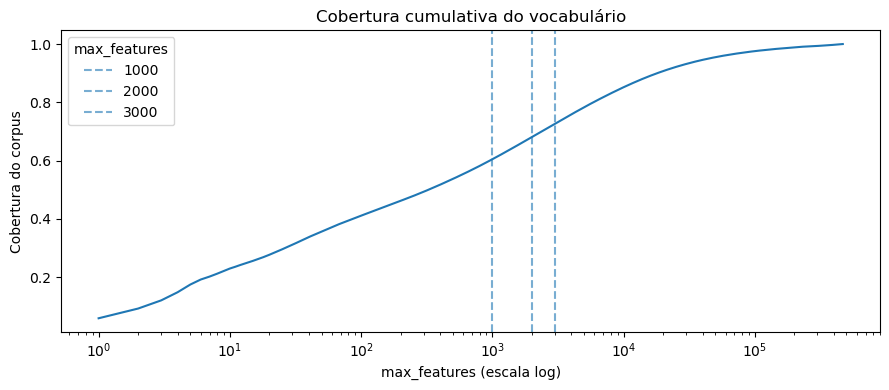

In [3]:
all_words = ' '.join(train_df['text'].astype(str).str.lower()).split()
counts = Counter(all_words)
print(f'Palavras únicas no treino: {len(counts):,}')

sorted_counts = np.array(sorted(counts.values(), reverse=True))
cumulative = np.cumsum(sorted_counts) / sorted_counts.sum()

for threshold in [0.80, 0.90, 0.95, 0.99]:
    n = np.searchsorted(cumulative, threshold) + 1
    print(f'  {threshold*100:.0f}% de cobertura: {n:,} palavras')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(np.arange(1, len(sorted_counts)+1), cumulative)
for n in [1000, 2000, 3000]:
    ax.axvline(n, linestyle='--', alpha=0.6, label=f'{n}')
ax.set_xscale('log')
ax.set_xlabel('max_features (escala log)')
ax.set_ylabel('Cobertura do corpus')
ax.set_title('Cobertura cumulativa do vocabulário')
ax.legend(title='max_features')
plt.tight_layout()
plt.show()


## 2 — Curva de validação: qual o melhor max_features?
Treina um MLP rápido para cada valor e compara o F1 macro na validação.

Vocabulário criado com 1000 palavras
  max_features=  1000 | val_acc=0.4560 | val_f1=0.4058
Vocabulário criado com 2000 palavras
  max_features=  2000 | val_acc=0.4640 | val_f1=0.4048


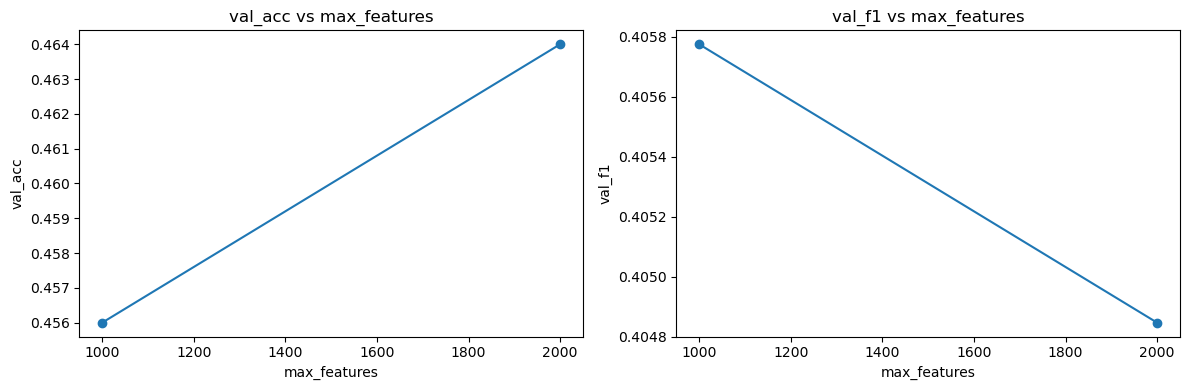


Melhor max_features: 1000 (val_f1=0.4058)


In [4]:
label_to_idx, idx_to_label = build_label_maps(CLASS_ORDER)
y_train = encode_labels(train_df['label'], label_to_idx)
y_val   = encode_labels(val_df['label'],   label_to_idx)

candidates = [1000, 2000]
results = []

for n in candidates:
    _, X_train, X_val = create_tfidf_features(train_df['text'], val_df['text'], max_features=n)
    train_loader, val_loader = make_dataloaders_from_arrays(X_train, y_train, X_val, y_val, batch_size=256)

    model = MLPClassifier(input_size=n, hidden_size=256, num_classes=5).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    run_training(model, train_loader, val_loader, criterion, optimizer, device,
                 epochs=15, patience=3, verbose=False)

    _, _, y_true, y_pred = evaluate(model, val_loader, criterion, device)
    metrics = compute_metrics(y_true, y_pred, list(range(5)))
    results.append({'max_features': n, 'val_acc': metrics['accuracy'], 'val_f1': metrics['macro_f1']})
    print(f'  max_features={n:>6} | val_acc={metrics["accuracy"]:.4f} | val_f1={metrics["macro_f1"]:.4f}')

results_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric in zip(axes, ['val_acc', 'val_f1']):
    ax.plot(results_df['max_features'], results_df[metric], marker='o')
    ax.set_xlabel('max_features')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} vs max_features')
plt.tight_layout()
plt.show()

best = results_df.loc[results_df['val_f1'].idxmax()]
print(f'\nMelhor max_features: {int(best.max_features)} (val_f1={best.val_f1:.4f})')


## 3 — Treino final com o melhor max_features

In [5]:
BEST_N = int(best.max_features) 

tfidf, X_train, X_val = create_tfidf_features(train_df['text'], val_df['text'], max_features=BEST_N)
X_test = tfidf.transform(test_df['text'].values).astype(np.float32)

y_test = encode_labels(test_df['label'], label_to_idx)
train_loader, val_loader = make_dataloaders_from_arrays(X_train, y_train, X_val, y_val, batch_size=256)

model = MLPClassifier(input_size=BEST_N, hidden_size=256, num_classes=5).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

history, best_state, best_epoch = run_training(
    model, train_loader, val_loader, criterion, optimizer, device,
    epochs=50, patience=5, verbose=True
)

model.load_state_dict(best_state)
print(f'\nMelhor epoch: {best_epoch}')


Vocabulário criado com 1000 palavras
Epoch 01/50 | train_loss=0.6982 train_acc=0.7735 | val_loss=1.6931 val_acc=0.4400
Epoch 02/50 | train_loss=0.4294 train_acc=0.8420 | val_loss=1.7398 val_acc=0.4640
Epoch 03/50 | train_loss=0.4043 train_acc=0.8511 | val_loss=1.7908 val_acc=0.4560
Epoch 04/50 | train_loss=0.3868 train_acc=0.8569 | val_loss=1.7882 val_acc=0.4400
Epoch 05/50 | train_loss=0.3715 train_acc=0.8629 | val_loss=1.7574 val_acc=0.4800
Epoch 06/50 | train_loss=0.3560 train_acc=0.8684 | val_loss=1.7452 val_acc=0.4880
Epoch 07/50 | train_loss=0.3415 train_acc=0.8741 | val_loss=1.7932 val_acc=0.4640
Epoch 08/50 | train_loss=0.3273 train_acc=0.8793 | val_loss=1.7914 val_acc=0.4640
Epoch 09/50 | train_loss=0.3127 train_acc=0.8849 | val_loss=1.8180 val_acc=0.4640
Epoch 10/50 | train_loss=0.2999 train_acc=0.8898 | val_loss=1.8193 val_acc=0.4800
Epoch 11/50 | train_loss=0.2869 train_acc=0.8946 | val_loss=1.8980 val_acc=0.4640
Early stopping at epoch 11 (best epoch=6, best val_acc=0.4880

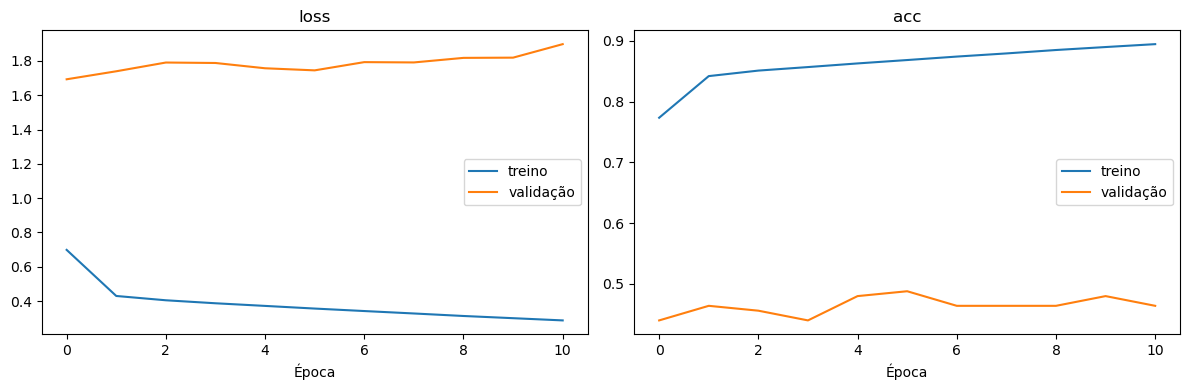

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric in zip(axes, [('train_loss','val_loss'), ('train_acc','val_acc')]):
    ax.plot(history[metric[0]], label='treino')
    ax.plot(history[metric[1]], label='validação')
    ax.set_xlabel('Época')
    ax.set_title(metric[1].replace('val_',''))
    ax.legend()
plt.tight_layout()
plt.show()

## 4 — Avaliação

In [7]:
from torch.utils.data import TensorDataset, DataLoader

# Avaliação no conjunto de validação (dataset do professor)
_, _, y_true_val, y_pred_val = evaluate(model, val_loader, criterion, device)
m_val = compute_metrics(y_true_val, y_pred_val, list(range(5)))
print('=== Validação (dataset professor) ===')
print(f'Accuracy: {m_val["accuracy"]:.4f} | Macro F1: {m_val["macro_f1"]:.4f}')
print(m_val['report'])

# Avaliação no conjunto de teste (20% dataset_final)
test_loader = DataLoader(
    TensorDataset(torch.tensor(X_test), torch.tensor(y_test)),
    batch_size=256, shuffle=False
)
_, _, y_true_test, y_pred_test = evaluate(model, test_loader, criterion, device)
m_test = compute_metrics(y_true_test, y_pred_test, list(range(5)))
print('=== Teste (20% dataset_final) ===')
print(f'Accuracy: {m_test["accuracy"]:.4f} | Macro F1: {m_test["macro_f1"]:.4f}')
print(m_test['report'])


=== Validação (dataset professor) ===
Accuracy: 0.4880 | Macro F1: 0.4417
              precision    recall  f1-score   support

           0       0.80      0.54      0.64        52
           1       0.73      0.50      0.59        16
           2       0.50      0.12      0.19        17
           3       0.24      0.47      0.32        17
           4       0.36      0.65      0.46        23

    accuracy                           0.49       125
   macro avg       0.53      0.46      0.44       125
weighted avg       0.59      0.49      0.50       125

=== Teste (20% dataset_final) ===
Accuracy: 0.8679 | Macro F1: 0.8679
              precision    recall  f1-score   support

           0       0.89      0.90      0.90     12000
           1       0.85      0.84      0.84     12000
           2       0.83      0.84      0.83     12000
           3       0.86      0.86      0.86     12000
           4       0.91      0.91      0.91     12000

    accuracy                           0.

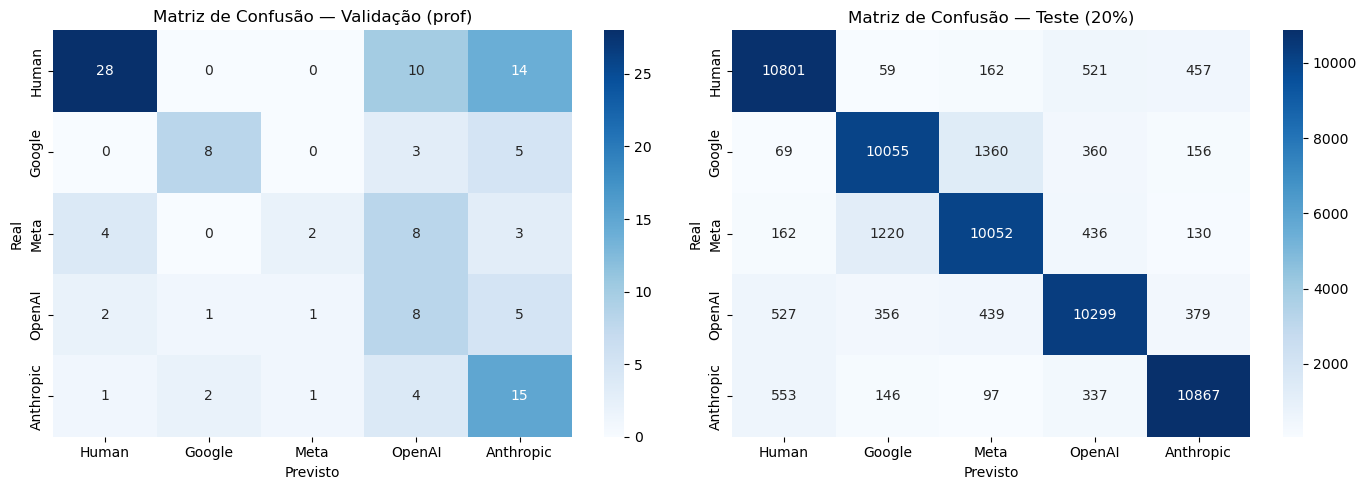

In [8]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (m, title) in zip(axes, [(m_val, 'Validação (prof)'), (m_test, 'Teste (20%)')]):
    sns.heatmap(m['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER, ax=ax)
    ax.set_xlabel('Previsto')
    ax.set_ylabel('Real')
    ax.set_title(f'Matriz de Confusão — {title}')
plt.tight_layout()
plt.show()


## 5 — Guardar modelo

In [9]:
import os, pickle
os.makedirs('../modelos', exist_ok=True)

torch.save(best_state, '../modelos/mlp_tfidf.pt')
with open('../modelos/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print('Modelo e vectorizador guardados.')

Modelo e vectorizador guardados.
